In [1]:
import sqlite3
import pandas as pd
import numpy as np
from tqdm import tqdm
import json

In [ ]:
SQLITE_PATH = "dev_ai_articles_full.sqlite"

DEV_COLUMN_CONFIG = {
    "id": "id",           # primary key column
    "title": "title",     # article title column
    "body": "body_text",       # article body/content column (set to None if not available)
}
dev_articles = "topic labeled articles"

# Number of characters per chunk for each article (split long articles into multiple chunks to avoid hitting model context length limits)
CHUNK_CHARS = 500

# Batch size for zero-shot classification (lower if you run out of RAM)
CLASSIFICATION_BATCH_SIZE = 32

In [3]:
conn = sqlite3.connect(SQLITE_PATH)
cursor = conn.cursor()

In [4]:
id_col = DEV_COLUMN_CONFIG["id"]
title_col = DEV_COLUMN_CONFIG["title"]
body_col = DEV_COLUMN_CONFIG["body"]

query = f'SELECT * FROM "{dev_articles}"'

df = pd.read_sql_query(query, conn)


# Vader sentiment

In [5]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


sia = SentimentIntensityAnalyzer()


In [6]:

def vader_sentiment(text):
    score = sia.polarity_scores(text[:2000])["compound"]
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"


non_tech_df = df.copy()

In [7]:
non_tech_df["sentiment"] = non_tech_df["combined_text"].apply(vader_sentiment)

In [8]:

print("Sentiment distribution:")
print(non_tech_df["sentiment"].value_counts())

Sentiment distribution:
sentiment
positive    4293
negative    1085
neutral       20
Name: count, dtype: int64


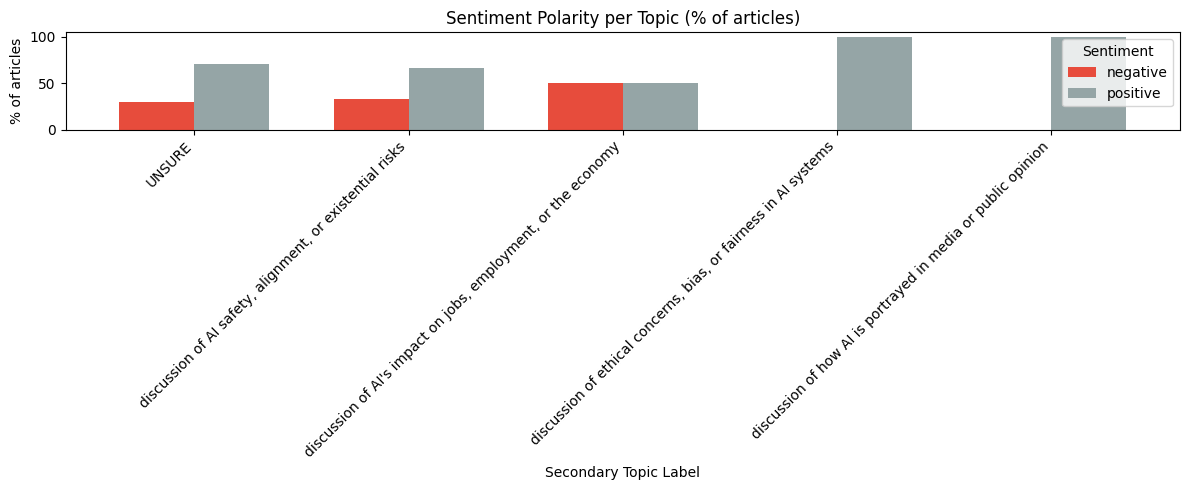

sentiment,negative,positive
secondary_label,,
UNSURE,29.411765,70.588235
"discussion of AI safety, alignment, or existential risks",33.333333,66.666667
"discussion of AI's impact on jobs, employment, or the economy",50.000000,50.000000
"discussion of ethical concerns, bias, or fairness in AI systems",0.000000,100.000000
discussion of how AI is portrayed in media or public opinion,0.000000,100.000000


In [9]:
import matplotlib.pyplot as plt
# Sentiment breakdown per secondary label
has_label = non_tech_df[non_tech_df["secondary_label"] != ""]
sent_cross = has_label.groupby(["secondary_label", "sentiment"]).size().unstack(fill_value=0)
sent_pct = sent_cross.div(sent_cross.sum(axis=1), axis=0) * 100

sent_pct.plot(kind="bar", figsize=(12, 5), color=["#e74c3c", "#95a5a6", "#2ecc71"], width=0.7)
plt.title("Sentiment Polarity per Topic (% of articles)")
plt.xlabel("Secondary Topic Label")
plt.ylabel("% of articles")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()
sent_pct

# TextBlob

In [10]:

from textblob import TextBlob
import pandas as pd

def textblob_sentiment(text: str):
    if not isinstance(text, str) or not text.strip():
        return 0.0, 0.0, "neutral"

    blob = TextBlob(text)
    polarity = blob.sentiment.polarity      # range: [-1, 1]
    subjectivity = blob.sentiment.subjectivity  # range: [0, 1]

    if polarity > 0.05:
        label = "positive"
    elif polarity < -0.05:
        label = "negative"
    else:
        label = "neutral"

    return polarity, subjectivity, label



non_tech_df[["tb_polarity", "tb_subjectivity", "tb_sentiment"]] = non_tech_df["combined_text"].apply(
	lambda x: pd.Series(textblob_sentiment(x))
)


In [11]:
non_tech_df

,id,title,body_text,combined_text,cluster,primary_label,primary_score,secondary_label,secondary_score,dominant_topic,dominant_topic_prob,sentiment,tb_polarity,tb_subjectivity,tb_sentiment
0,585948,Diamond Hands and the Mechanics of a Short Squ...,title: Diamond Hands and the Mechanics of a Sh...,Diamond Hands and the Mechanics of a Short Squ...,8,UNSURE,0.000000,,0.0,0,0.620216,positive,-0.007114,0.449539,neutral
1,604165,12 Important Software Testing Trends for 2021 ...,Software testing is making many moves. From AI...,12 Important Software Testing Trends for 2021 ...,3,UNSURE,0.000000,,0.0,0,0.800833,positive,0.131818,0.506764,positive
2,628993,"Another 8th of March, yet we are not still there!",Where are we about equality in tech in 2021? A...,"Another 8th of March, yet we are not still the...",3,UNSURE,0.000000,,0.0,0,0.769863,negative,0.042257,0.527893,neutral
3,645109,Top Automation Testing Trends To Look Out In 2021,"Back in the old days, software testing was jus...",Top Automation Testing Trends To Look Out In 2...,3,UNSURE,0.000000,,0.0,0,0.745716,positive,0.159180,0.347962,positive
4,971871,How Cryptocurrency Works Explained Visually,"In 2008, when Lehman Brothers Holdings Inc. fi...",How Cryptocurrency Works Explained Visually In...,8,UNSURE,0.000000,,0.0,3,0.516454,positive,0.047751,0.350094,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5393,69ae116a86766ac3a663b05f,The Copper Ceiling: AI's High-Voltage Collisio...,"When we interact with artificial intelligence,...",The Copper Ceiling: AI's High-Voltage Collisio...,3,TECHNICAL,0.291620,,0.0,4,0.604514,positive,-0.005018,0.483132,neutral
5394,699d48cad00f02a90785119e,Physical AI: Why the Grid’s Operating System S...,As someone working in Developer Relations in t...,Physical AI: Why the Grid’s Operating System S...,3,TECHNICAL,0.263547,,0.0,0,0.565836,positive,0.089474,0.269173,positive
5395,69a889213b896f7ad6749182,I Thought AI Made Me Faster. My Metrics Disagr...,"Friday, 4:47 PM. A PR lands in the repo with a...",I Thought AI Made Me Faster. My Metrics Disagr...,3,TECHNICAL,0.331377,,0.0,0,0.988272,positive,0.148611,0.572222,positive
5396,69a8580ae55311e40f0fd641,You don't know your AI stack.,AI tooling has no supply chain. No audit trail...,You don't know your AI stack. AI tooling has n...,3,TECHNICAL,0.603208,,0.0,0,0.881674,positive,0.105644,0.398469,positive


,tb_sentiment,count,percent
0,positive,3682,68.21
1,neutral,1528,28.31
2,negative,188,3.48


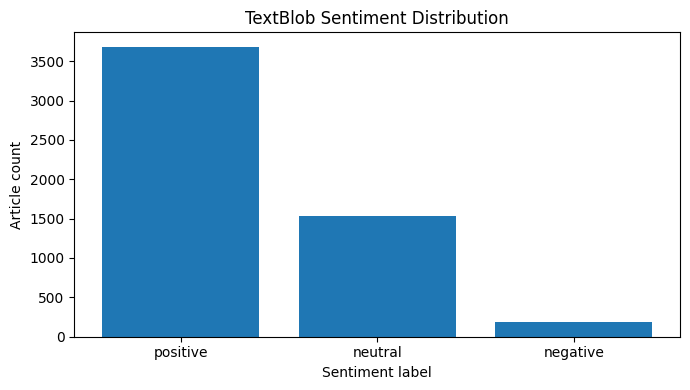

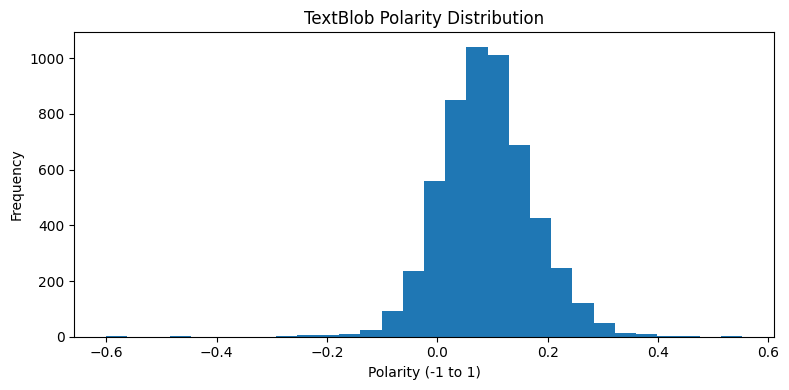

In [12]:


# Count and percentage distribution by sentiment label
textblob_dist = (
    non_tech_df["tb_sentiment"]
    .value_counts(dropna=False)
    .rename_axis("tb_sentiment")
    .reset_index(name="count")
)
textblob_dist["percent"] = (textblob_dist["count"] / textblob_dist["count"].sum() * 100).round(2)

display(textblob_dist)

# Bar chart of label distribution
plt.figure(figsize=(7, 4))
plt.bar(textblob_dist["tb_sentiment"], textblob_dist["count"])
plt.title("TextBlob Sentiment Distribution")
plt.xlabel("Sentiment label")
plt.ylabel("Article count")
plt.tight_layout()
plt.show()

# Histogram of TextBlob polarity values
plt.figure(figsize=(8, 4))
plt.hist(non_tech_df["tb_polarity"].dropna(), bins=30)
plt.title("TextBlob Polarity Distribution")
plt.xlabel("Polarity (-1 to 1)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# RoBERTa

In [ ]:
from transformers import pipeline, AutoTokenizer, AutoConfig
 
MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
config = AutoConfig.from_pretrained(MODEL)
 
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=MODEL,
    tokenizer=tokenizer,
    truncation=True,
    max_length=512,
)